✅ All libraries imported successfully!
🖥️  Device: cuda
🔥 GPU Name: Tesla T4
📥 Creating Sorted CSV Files...
📁 Benign: 467 images → ./dataset_csvs/benign_dataset.csv
   Train: 1-326 | Val: 327-373 | Test: 374-467
📁 Malignant: 1050 images → ./dataset_csvs/malignant_dataset.csv
   Train: 1-735 | Val: 736-839 | Test: 840-1050
📁 Normal: 416 images → ./dataset_csvs/normal_dataset.csv
   Train: 1-291 | Val: 292-332 | Test: 333-416

📊 Combined dataset saved: ./dataset_csvs/full_dataset.csv

📊 Split Summary from CSV:

TRAIN: 1352 images
class_name
Malignant    735
Benign       326
Normal       291

VAL: 192 images
class_name
Malignant    104
Benign        47
Normal        41

TEST: 389 images
class_name
Malignant    211
Benign        94
Normal        84

📥 Loading Images from CSV...


Loading: 100%|██████████| 389/389 [00:02<00:00, 131.12it/s]



✅ Train: 1352 | Val: 192 | Test: 389
📊 Train distribution: {np.int64(0): 326, np.int64(1): 735, np.int64(2): 291}
📊 Val distribution:   {np.int64(0): 47, np.int64(1): 104, np.int64(2): 41}
📊 Test distribution:  {np.int64(0): 94, np.int64(1): 211, np.int64(2): 84}

🔄 Augmenting Training Data Only...
  Benign: 326 original + 3007 augmented → 3333
  Malignant: 735 original + 2598 augmented → 3333
  Normal: 291 original + 3042 augmented → 3333

✅ Augmented Training: 9999 images
📊 Balanced distribution: {np.int64(0): 3333, np.int64(1): 3333, np.int64(2): 3333}

⚠️ Val/Test sets unchanged (no augmentation applied)


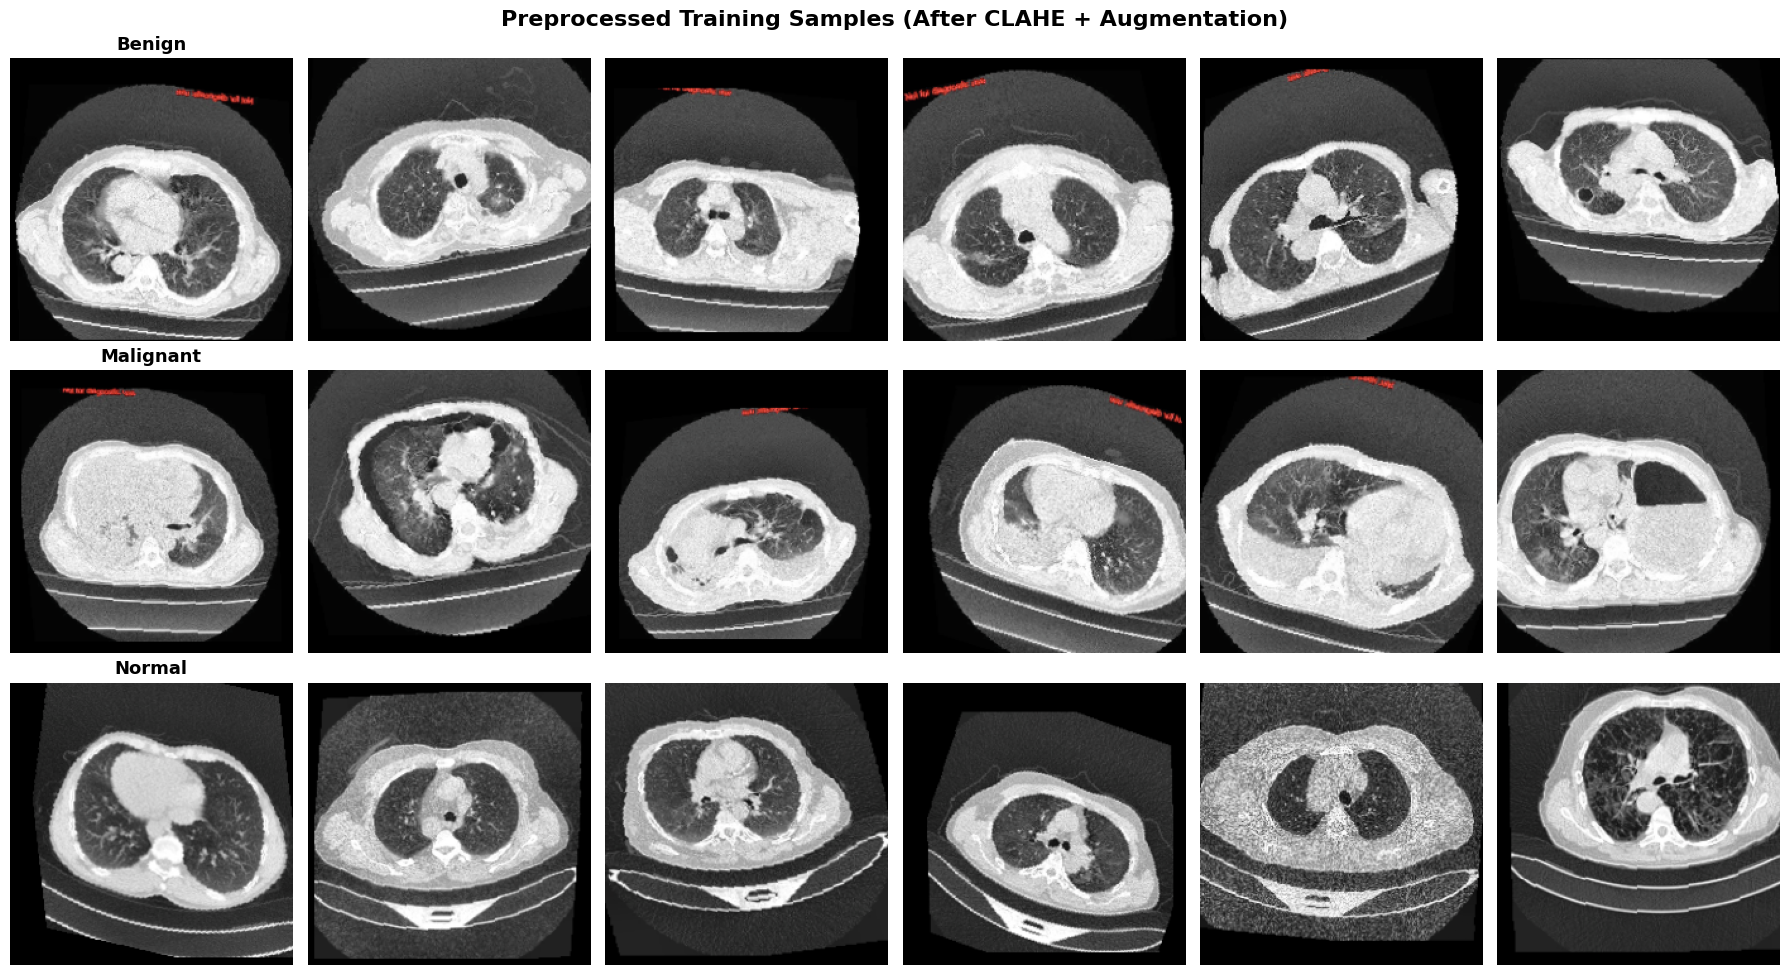

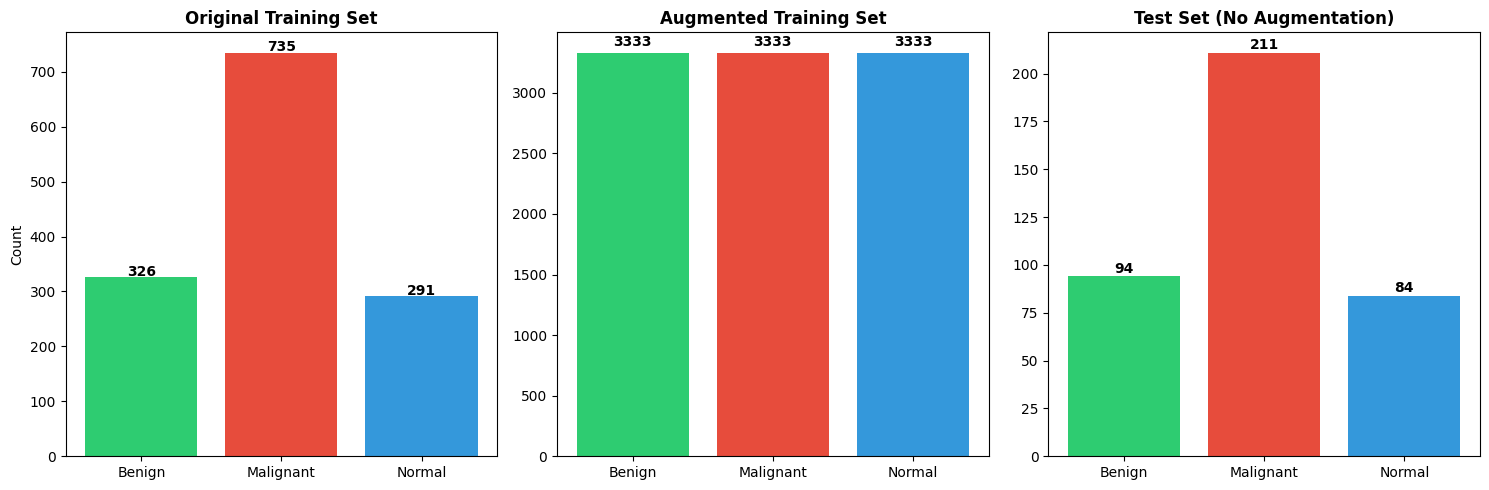


✅ Preprocessing complete!
   X_train_aug: (9999, 224, 224, 3)
   X_val:       (192, 224, 224, 3)
   X_test:      (389, 224, 224, 3)

📦 Datasets created — Train: 9999 | Val: 192 | Test: 389
   (DataLoaders will be created in Section 2 using CONFIG batch_size)


In [1]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  SECTION 1 — IMPORTS & PREPROCESSING                                       ║
# ║  No experiment config here. This cell is purely data-pipeline.             ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ── 1.1  Installs ────────────────────────────────────────────────────────────
!pip install -q wandb

# ── 1.2  Imports ─────────────────────────────────────────────────────────────
import os, random, math, copy, time, glob, warnings
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
from torchvision import transforms
from torchvision.transforms import functional as TF

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, accuracy_score,
    precision_score, recall_score, f1_score,
)
from sklearn.preprocessing import label_binarize

import wandb

warnings.filterwarnings('ignore')
print("✅ All libraries imported successfully!")

# ── 1.3  Seed & Device ──────────────────────────────────────────────────────
SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"🔥 GPU Name: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ No GPU detected. Training will be slow on CPU.")

SAVE_DIR = './saved_models'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── 1.4  Dataset Constants (data-level, NOT experiment config) ───────────────
DATA_DIR   = '/kaggle/input/datasets/tahmidulkashfi/new-chest/An Image Dataset of Advanced Imaging Techniques for Lung Cancer Diagnosis/Lung Cancer Diagnosis Dataset/Dataset'
IMG_SIZE   = 224
NUM_CLASSES = 3
CLASS_NAMES  = ['Bengin cases', 'Malignant cases', 'Normal cases']   # folder names
CLASS_LABELS = ['Benign', 'Malignant', 'Normal']                     # display names

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.10
TEST_RATIO  = 0.20

# ── 1.5  Create Sorted CSV Files ────────────────────────────────────────────
def create_class_csv(data_dir, class_names, output_dir='.'):
    """Create sorted CSV files for each class with train/val/test split."""
    os.makedirs(output_dir, exist_ok=True)
    all_data = []

    for cls_idx, cls_name in enumerate(class_names):
        cls_path = os.path.join(data_dir, cls_name)
        if not os.path.isdir(cls_path):
            print(f"⚠️ Directory not found: {cls_path}")
            continue

        files = sorted([f for f in os.listdir(cls_path)
                        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))])
        n_files = len(files)
        train_end = int(n_files * TRAIN_RATIO)
        val_end   = int(n_files * (TRAIN_RATIO + VAL_RATIO))

        class_data = []
        for i, fname in enumerate(files):
            split = 'train' if i < train_end else ('val' if i < val_end else 'test')
            class_data.append({
                'index': i + 1,
                'filename': fname,
                'filepath': os.path.join(cls_path, fname),
                'class_idx': cls_idx,
                'class_name': CLASS_LABELS[cls_idx],
                'split': split,
            })

        df_class = pd.DataFrame(class_data)
        csv_path = os.path.join(output_dir, f'{CLASS_LABELS[cls_idx].lower()}_dataset.csv')
        df_class.to_csv(csv_path, index=False)
        print(f"📁 {CLASS_LABELS[cls_idx]}: {n_files} images → {csv_path}")
        print(f"   Train: 1-{train_end} | Val: {train_end+1}-{val_end} | Test: {val_end+1}-{n_files}")
        all_data.extend(class_data)

    df_all = pd.DataFrame(all_data)
    combined_path = os.path.join(output_dir, 'full_dataset.csv')
    df_all.to_csv(combined_path, index=False)
    print(f"\n📊 Combined dataset saved: {combined_path}")
    return df_all

print("=" * 60)
print("📥 Creating Sorted CSV Files...")
print("=" * 60)
df_dataset = create_class_csv(DATA_DIR, CLASS_NAMES, output_dir='./dataset_csvs')

print("\n" + "=" * 60)
print("📊 Split Summary from CSV:")
print("=" * 60)
for split in ['train', 'val', 'test']:
    split_df = df_dataset[df_dataset['split'] == split]
    print(f"\n{split.upper()}: {len(split_df)} images")
    print(split_df['class_name'].value_counts().to_string())

# ── 1.6  CLAHE & Image Loading ──────────────────────────────────────────────
def apply_clahe(image):
    """Apply CLAHE to enhance contrast."""
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

def load_images_from_csv(df, img_size=224):
    """Load and preprocess images based on CSV dataframe."""
    images, labels = [], []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Loading"):
        try:
            img = cv2.imread(row['filepath'])
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (img_size, img_size))
            img = apply_clahe(img)
            img = img.astype(np.float32) / 255.0
            images.append(img)
            labels.append(row['class_idx'])
        except Exception as e:
            print(f"Error loading {row['filepath']}: {e}")
    return np.array(images), np.array(labels)

print("\n" + "=" * 60)
print("📥 Loading Images from CSV...")
print("=" * 60)

df_train = df_dataset[df_dataset['split'] == 'train']
df_val   = df_dataset[df_dataset['split'] == 'val']
df_test  = df_dataset[df_dataset['split'] == 'test']

X_train, y_train = load_images_from_csv(df_train, IMG_SIZE)
X_val,   y_val   = load_images_from_csv(df_val,   IMG_SIZE)
X_test,  y_test  = load_images_from_csv(df_test,  IMG_SIZE)

print(f"\n✅ Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print(f"📊 Train distribution: {dict(Counter(y_train))}")
print(f"📊 Val distribution:   {dict(Counter(y_val))}")
print(f"📊 Test distribution:  {dict(Counter(y_test))}")

# ── 1.7  Augment Training Data ──────────────────────────────────────────────
def augment_image(image_np):
    """Apply random augmentations to a single image."""
    img = Image.fromarray((image_np * 255).astype(np.uint8))
    angle = random.uniform(-20, 20)
    img = TF.rotate(img, angle, fill=0)
    max_shift = int(IMG_SIZE * 0.1)
    dx, dy = random.randint(-max_shift, max_shift), random.randint(-max_shift, max_shift)
    img = TF.affine(img, angle=0, translate=(dx, dy), scale=1.0, shear=0)
    shear_deg = random.uniform(-10, 10)
    img = TF.affine(img, angle=0, translate=(0, 0), scale=1.0, shear=shear_deg)
    scale = random.uniform(0.9, 1.1)
    new_size = int(IMG_SIZE * scale)
    img = img.resize((new_size, new_size), Image.BILINEAR)
    img = TF.center_crop(img, [IMG_SIZE, IMG_SIZE])
    if random.random() > 0.5:
        img = TF.hflip(img)
    return np.array(img).astype(np.float32) / 255.0

def augment_training_data(X_train, y_train, target_per_class=3333):
    """Augment training images to balance classes."""
    aug_images, aug_labels = [], []
    for cls_idx in range(NUM_CLASSES):
        cls_mask = y_train == cls_idx
        cls_images = X_train[cls_mask]
        n_current = len(cls_images)
        n_needed = target_per_class - n_current
        aug_images.extend(cls_images)
        aug_labels.extend([cls_idx] * n_current)
        print(f"  {CLASS_LABELS[cls_idx]}: {n_current} original + {max(0, n_needed)} augmented → {target_per_class}")
        for i in range(max(0, n_needed)):
            aug_images.append(augment_image(cls_images[i % n_current]))
            aug_labels.append(cls_idx)
    return np.array(aug_images), np.array(aug_labels)

print("\n" + "=" * 60)
print("🔄 Augmenting Training Data Only...")
print("=" * 60)
TARGET_PER_CLASS = 3333
X_train_aug, y_train_aug = augment_training_data(X_train, y_train, TARGET_PER_CLASS)
print(f"\n✅ Augmented Training: {len(X_train_aug)} images")
print(f"📊 Balanced distribution: {dict(Counter(y_train_aug))}")
print(f"\n⚠️ Val/Test sets unchanged (no augmentation applied)")

# ── 1.8  Visualization ──────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 6, figsize=(18, 10))
fig.suptitle('Preprocessed Training Samples (After CLAHE + Augmentation)',
             fontsize=16, fontweight='bold')
for row, cls_idx in enumerate(range(NUM_CLASSES)):
    cls_mask = y_train_aug == cls_idx
    cls_imgs = X_train_aug[cls_mask]
    sample_indices = np.random.choice(len(cls_imgs), 6, replace=False)
    for col, idx in enumerate(sample_indices):
        axes[row, col].imshow(cls_imgs[idx])
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(f'{CLASS_LABELS[cls_idx]}',
                                     fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('preprocessed_samples.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
orig_dist = Counter(y_train)
axes[0].bar(CLASS_LABELS, [orig_dist[i] for i in range(3)],
            color=['#2ecc71', '#e74c3c', '#3498db'])
axes[0].set_title('Original Training Set', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate([orig_dist[i] for i in range(3)]):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

aug_dist = Counter(y_train_aug)
axes[1].bar(CLASS_LABELS, [aug_dist[i] for i in range(3)],
            color=['#2ecc71', '#e74c3c', '#3498db'])
axes[1].set_title('Augmented Training Set', fontweight='bold')
for i, v in enumerate([aug_dist[i] for i in range(3)]):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')

test_dist = Counter(y_test)
axes[2].bar(CLASS_LABELS, [test_dist[i] for i in range(3)],
            color=['#2ecc71', '#e74c3c', '#3498db'])
axes[2].set_title('Test Set (No Augmentation)', fontweight='bold')
for i, v in enumerate([test_dist[i] for i in range(3)]):
    axes[2].text(i, v + 2, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Preprocessing complete!")
print(f"   X_train_aug: {X_train_aug.shape}")
print(f"   X_val:       {X_val.shape}")
print(f"   X_test:      {X_test.shape}")

# ── 1.9  PyTorch Datasets ────────────────────────────────────────────────────
class LungCancerDataset(Dataset):
    """Custom PyTorch Dataset for lung cancer CT images."""
    def __init__(self, images, labels, augment=False):
        self.images = images
        self.labels = labels
        self.augment = augment
        self.transform = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.3),
            transforms.RandomRotation(10),
        ]) if augment else None

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = torch.tensor(self.images[idx], dtype=torch.float32).permute(2, 0, 1)
        if self.transform:
            image = self.transform(image)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return image, label

train_dataset = LungCancerDataset(X_train_aug, y_train_aug, augment=True)
val_dataset   = LungCancerDataset(X_val,   y_val,   augment=False)
test_dataset  = LungCancerDataset(X_test,  y_test,  augment=False)

print(f"\n📦 Datasets created — Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
print("   (DataLoaders will be created in Section 2 using CONFIG batch_size)")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


✅ CONFIG loaded
   Model : DepthWiseMamba-Pico
   Epochs: 50
   Optim : Adam  lr=0.0001
   Sched : None
   W&B   : ON

📦 Train loader: 9999 samples, 157 batches
📦 Val loader:   192 samples, 3 batches
📦 Test loader:  389 samples, 7 batches
✅ DSMaT architecture defined
🏗️  DepthWiseMamba-Pico | Params: 837,166 (0.84M)
✅ Training utilities defined


✅ W&B run initialised

🚀 Starting training for DepthWiseMamba-Pico3...
  Ep   1/50 | Tr 0.5876/0.7024 | Val 0.4896/0.6979 | 20.9s ★ saved
  Ep   2/50 | Tr 0.3963/0.8001 | Val 0.4771/0.7188 | 20.1s ★ saved
  Ep   3/50 | Tr 0.3553/0.8271 | Val 0.4656/0.7344 | 20.0s ★ saved
  Ep   4/50 | Tr 0.3118/0.8533 | Val 0.4507/0.7292 | 20.0s
  Ep   5/50 | Tr 0.2901/0.8653 | Val 0.4041/0.7448 | 20.1s ★ saved
  Ep   6/50 | Tr 0.2744/0.8766 | Val 0.4058/0.7865 | 20.0s ★ saved
  Ep   7/50 | Tr 0.2490/0.8927 | Val 0.4430/0.7292 | 19.9s
  Ep   8/50 | Tr 0.2335/0.8972 | Val 0.4039/0.7865 | 19.8s
  Ep   9/50 | Tr 0.2111/0.9081 | Val 0.4003/0.8177 | 20.0s ★ saved
  Ep  10/50 | Tr 0.2013/0.9151 | Val 0.3323/0.8490 | 20.0s ★ saved
  Ep  11/50 | Tr 0.1846/0.9247 | Val 0.4369/0.7812 | 19.7s
  Ep  12/50 | Tr 0.1811/0.9260 | Val 0.3773/0.8125 | 19.8s
  Ep  13/50 | Tr 0.1666/0.9332 | Val 0.4895/0.7917 | 19.6s
  Ep  14/50 | Tr 0.1644/0.9342 | Val 0.4486/0.8385 | 19.8s
  Ep  15/50 | Tr 0.1617/0.9360 | Val 0.3512/0.8

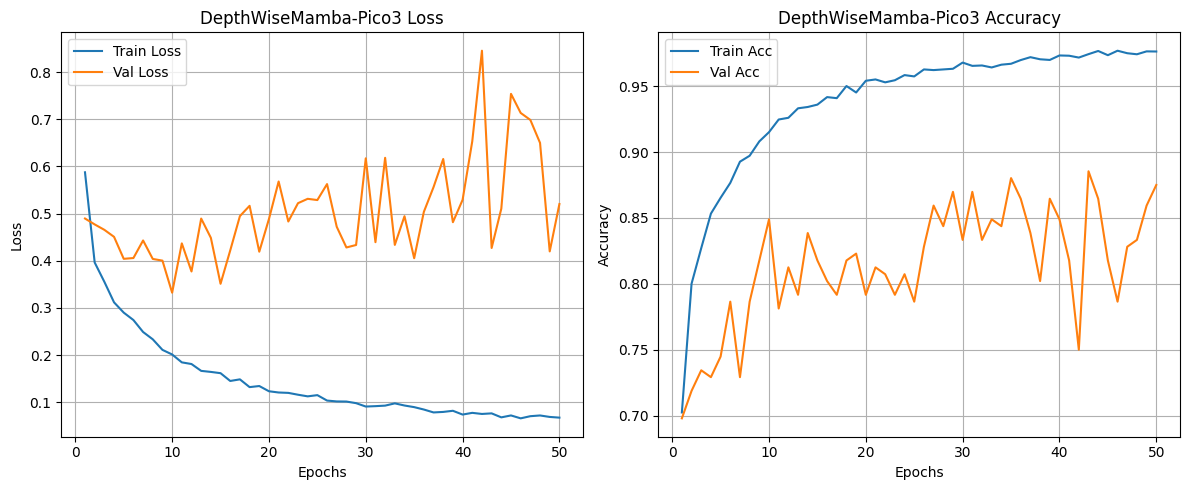

  TEST EVALUATION: DepthWiseMamba-Pico3 | Test Acc: 80.21%
              precision    recall  f1-score   support

      Benign       0.58      0.64      0.61        94
   Malignant       0.83      0.80      0.81       211
      Normal       1.00      1.00      1.00        84

    accuracy                           0.80       389
   macro avg       0.80      0.81      0.81       389
weighted avg       0.81      0.80      0.80       389



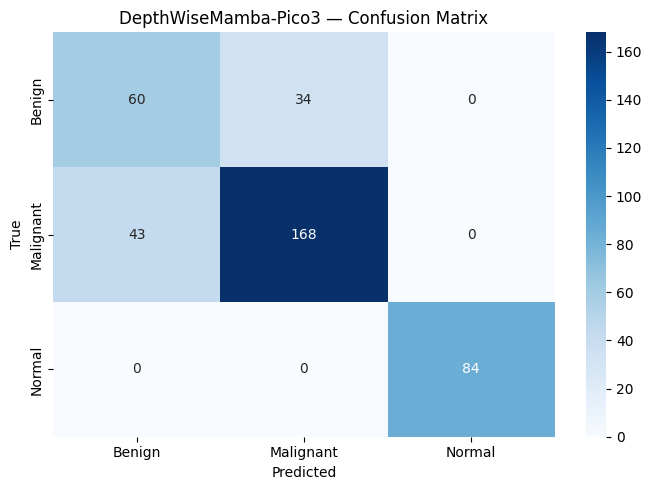

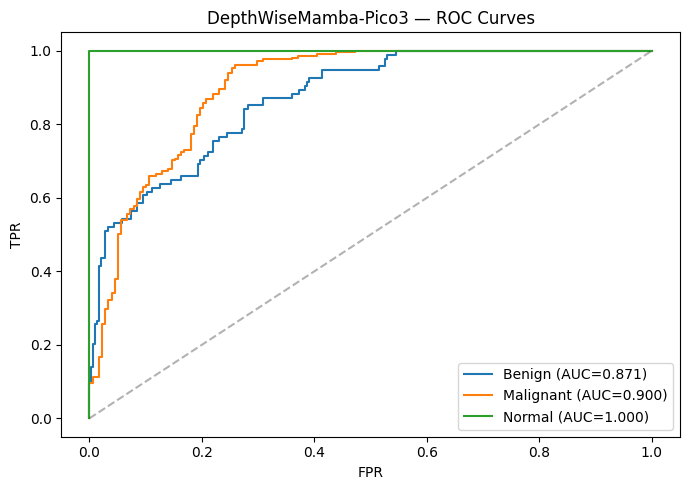

epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test_acc,▁
test_f1_macro,▁
test_loss,▁
train_acc,▁▃▄▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇█████████████████████
train_loss,█▅▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▂▂▂▃▂▄▅▇▄▅▆▅▅▅▆▅▅▅▅▄▆▇▆▇▇▆▇▆█▆▅▇▅█▅▄▆▆█
val_loss,▃▃▂▂▃▂▁▂▂▃▁▂▃▄▂▄▃▄▄▄▃▂▂▅▂▂▃▂▃▄▃▄▅█▂▇▆▆▅▄
epoch,50
lr,0.0001



✅ W&B run finished — config, metrics, and evaluation logged.

🏆 DepthWiseMamba-Pico3 | Test Acc: 80.21% | Saved: ./saved_models/DepthWiseMamba-Pico3_best.pth
✅ Done!


In [11]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  SECTION 2 — CONFIG + MODELS + TRAINING + EVALUATION                       ║
# ║  Everything is driven by the single CONFIG dict below.                     ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ═══════════════════════════════════════════════════════════════════════════════
# 2.1  UNIFIED EXPERIMENT CONFIG
# ═══════════════════════════════════════════════════════════════════════════════

CONFIG = {
    # ── Data ──────────────────────────────────────────────────────────────────
    "batch_size": 64,
    "num_workers": 4,

    # ── Model Selection ──────────────────────────────────────────────────────
    #   Pick ONE: "DepthWiseMamba-Pico" | "DepthwiseMamba-Nano"
    "model_name": "DepthWiseMamba-Pico",

    # ── Model Architecture Hyperparameters ───────────────────────────────────
    "model": {
        "DepthWiseMamba-Pico": {
            "stem_channels":  (16, 32),
            "stage_channels": (48, 96, 128, 192),
            "stage_depths":   (1, 1, 2, 2),
            "sa_heads":       (4, 4),
            "mlp_expand":     2,
            "dropout":        0.2,
        },
        "DepthwiseMamba-Nano": {
            "stem_channels":  (24, 48),
            "stage_channels": (64, 128, 192, 256),
            "stage_depths":   (1, 2, 2, 2),
            "sa_heads":       (4, 4),
            "mlp_expand":     3,
            "dropout":        0.4,
        },
    },

    # ── Training ─────────────────────────────────────────────────────────────
    "epochs": 50,
    "optimizer": "Adam",           # "AdamW" | "Adam" | "SGD"
    "optimizer_params": {
        "lr":           1e-4,
        "weight_decay": 1e-3,
    },
    "scheduler": None,   # "CosineAnnealingLR" | "StepLR" | "ReduceLROnPlateau" | None
    "scheduler_params": {},              # extra kwargs forwarded to the scheduler
    "grad_clip_max_norm": 1.0,

    # ── W&B ──────────────────────────────────────────────────────────────────
    "wandb_project": "DSMaT-LungCancer",
    "wandb_enabled": True,
}

print("✅ CONFIG loaded")
print(f"   Model : {CONFIG['model_name']}")
print(f"   Epochs: {CONFIG['epochs']}")
print(f"   Optim : {CONFIG['optimizer']}  lr={CONFIG['optimizer_params']['lr']}")
print(f"   Sched : {CONFIG['scheduler']}")
print(f"   W&B   : {'ON' if CONFIG['wandb_enabled'] else 'OFF'}")

# ═══════════════════════════════════════════════════════════════════════════════
# 2.2  DATALOADERS  (uses CONFIG["batch_size"])
# ═══════════════════════════════════════════════════════════════════════════════

train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"],
                          shuffle=True,  num_workers=CONFIG["num_workers"], pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=CONFIG["batch_size"],
                          shuffle=False, num_workers=CONFIG["num_workers"], pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=CONFIG["batch_size"],
                          shuffle=False, num_workers=CONFIG["num_workers"], pin_memory=True)

print(f"\n📦 Train loader: {len(train_dataset)} samples, {len(train_loader)} batches")
print(f"📦 Val loader:   {len(val_dataset)} samples, {len(val_loader)} batches")
print(f"📦 Test loader:  {len(test_dataset)} samples, {len(test_loader)} batches")

# ═══════════════════════════════════════════════════════════════════════════════
# 2.3  MODEL ARCHITECTURE
# ═══════════════════════════════════════════════════════════════════════════════

# ── Building Blocks ──────────────────────────────────────────────────────────

class DSConv2d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, stride=1, padding=1, bias=False):
        super().__init__()
        self.dw = nn.Conv2d(in_ch, in_ch, kernel_size, stride, padding, groups=in_ch, bias=False)
        self.pw = nn.Conv2d(in_ch, out_ch, 1, bias=bias)
    def forward(self, x):
        return self.pw(self.dw(x))

class DSConvStem(nn.Module):
    def __init__(self, in_ch=3, mid_ch=32, out_ch=64):
        super().__init__()
        self.stem = nn.Sequential(
            DSConv2d(in_ch, mid_ch, 3, stride=2, padding=1),
            nn.BatchNorm2d(mid_ch), nn.GELU(),
            DSConv2d(mid_ch, out_ch, 3, stride=2, padding=1),
            nn.BatchNorm2d(out_ch), nn.GELU(),
        )
    def forward(self, x):
        return self.stem(x)

class DSConvResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            DSConv2d(channels, channels, 3, 1, 1),
            nn.BatchNorm2d(channels), nn.GELU(),
            DSConv2d(channels, channels, 3, 1, 1),
            nn.BatchNorm2d(channels),
        )
    def forward(self, x):
        return self.block(x) + x

class DSConvDownsample(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.down = nn.Sequential(
            DSConv2d(in_ch, out_ch, 3, stride=2, padding=1),
            nn.BatchNorm2d(out_ch),
        )
    def forward(self, x):
        return self.down(x)

# ── Mamba / Attention / MLP ──────────────────────────────────────────────────

class SelectiveScan(nn.Module):
    def __init__(self, d_inner, d_state=16):
        super().__init__()
        self.d_state = d_state
        self.dt_rank = max(1, d_inner // 16)
        self.x_proj  = nn.Linear(d_inner, self.dt_rank + 2 * d_state, bias=False)
        self.dt_proj = nn.Linear(self.dt_rank, d_inner, bias=True)
        A = torch.arange(1, d_state + 1, dtype=torch.float32).unsqueeze(0).expand(d_inner, -1)
        self.A_log = nn.Parameter(torch.log(A))
        self.D     = nn.Parameter(torch.ones(d_inner))

    def forward(self, x):
        B_batch, D, L = x.shape
        x_seq = x.transpose(1, 2)
        x_dbl = self.x_proj(x_seq)
        dt_raw, B_param, C_param = x_dbl.split(
            [self.dt_rank, self.d_state, self.d_state], dim=-1)
        dt = F.softplus(self.dt_proj(dt_raw))
        A  = -torch.exp(self.A_log)
        dA  = torch.exp(dt.unsqueeze(-1) * A)
        dBx = dt.unsqueeze(-1) * B_param.unsqueeze(2)
        h = torch.zeros(B_batch, D, self.d_state, device=x.device, dtype=x.dtype)
        ys = []
        for t in range(L):
            h = dA[:, t] * h + dBx[:, t] * x_seq[:, t, :, None]
            yt = (h * C_param[:, t, None, :]).sum(-1)
            ys.append(yt)
        y = torch.stack(ys, dim=2)
        return y + self.D.unsqueeze(0).unsqueeze(-1) * x

class MambaVisionMixer(nn.Module):
    def __init__(self, dim, d_state=16, kernel_size=3):
        super().__init__()
        half = dim // 2
        self.proj_x   = nn.Linear(dim, half, bias=False)
        self.conv1d_x = nn.Conv1d(half, half, kernel_size, padding='same', groups=half)
        self.ssm      = SelectiveScan(half, d_state)
        self.proj_z   = nn.Linear(dim, half, bias=False)
        self.conv1d_z = nn.Conv1d(half, half, kernel_size, padding='same', groups=half)
        self.out_proj = nn.Linear(dim, dim)
        self.norm     = nn.LayerNorm(dim)

    def forward(self, x):
        residual = x
        x = self.norm(x)
        x1 = self.proj_x(x).transpose(1, 2)
        x1 = F.silu(self.conv1d_x(x1))
        x1 = self.ssm(x1)
        x2 = self.proj_z(x).transpose(1, 2)
        x2 = F.silu(self.conv1d_z(x2))
        out = torch.cat([x1, x2], dim=1).transpose(1, 2)
        return self.out_proj(out) + residual

class SelfAttentionBlock(nn.Module):
    def __init__(self, dim, num_heads=4, dropout=0.1):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
    def forward(self, x):
        normed = self.norm(x)
        out, _ = self.attn(normed, normed, normed)
        return out + x

class MLPBlock(nn.Module):
    def __init__(self, dim, expand=4, dropout=0.1):
        super().__init__()
        hidden = dim * expand
        self.net = nn.Sequential(
            nn.LayerNorm(dim), nn.Linear(dim, hidden), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(hidden, dim), nn.Dropout(dropout),
        )
    def forward(self, x):
        return self.net(x) + x

class MambaVisionLayer(nn.Module):
    def __init__(self, dim, mixer_type='mamba', num_heads=4,
                 d_state=16, mlp_expand=4, dropout=0.1):
        super().__init__()
        if mixer_type == 'mamba':
            self.mixer = MambaVisionMixer(dim, d_state=d_state)
        else:
            self.mixer = SelfAttentionBlock(dim, num_heads=num_heads, dropout=dropout)
        self.mlp = MLPBlock(dim, expand=mlp_expand, dropout=dropout)
    def forward(self, x):
        return self.mlp(self.mixer(x))

# ── DSMaT Full Model ─────────────────────────────────────────────────────────

class DSMaT(nn.Module):
    def __init__(self, stem_channels=(32, 64), stage_channels=(96, 192, 256, 384),
                 stage_depths=(2, 2, 4, 4), sa_heads=(4, 8), d_state=16,
                 mlp_expand=4, num_classes=3, dropout=0.2):
        super().__init__()
        stem_mid, stem_out = stem_channels
        self.stem = DSConvStem(3, stem_mid, stem_out)

        self.down1  = DSConvDownsample(stem_out, stage_channels[0])
        self.stage1 = nn.Sequential(*[DSConvResBlock(stage_channels[0])
                                      for _ in range(stage_depths[0])])

        self.down2  = DSConvDownsample(stage_channels[0], stage_channels[1])
        self.stage2 = nn.Sequential(*[DSConvResBlock(stage_channels[1])
                                      for _ in range(stage_depths[1])])

        self.down3 = DSConvDownsample(stage_channels[1], stage_channels[2])
        n3 = stage_depths[2]; n3m = n3 // 2; n3a = n3 - n3m
        s3 = []
        for _ in range(n3m):
            s3.append(MambaVisionLayer(stage_channels[2], 'mamba',
                      d_state=d_state, mlp_expand=mlp_expand, dropout=dropout))
        for _ in range(n3a):
            s3.append(MambaVisionLayer(stage_channels[2], 'attention',
                      num_heads=sa_heads[0], mlp_expand=mlp_expand, dropout=dropout))
        self.stage3 = nn.ModuleList(s3)

        self.down4 = DSConvDownsample(stage_channels[2], stage_channels[3])
        n4 = stage_depths[3]; n4m = n4 // 2; n4a = n4 - n4m
        s4 = []
        for _ in range(n4m):
            s4.append(MambaVisionLayer(stage_channels[3], 'mamba',
                      d_state=d_state, mlp_expand=mlp_expand, dropout=dropout))
        for _ in range(n4a):
            s4.append(MambaVisionLayer(stage_channels[3], 'attention',
                      num_heads=sa_heads[1], mlp_expand=mlp_expand, dropout=dropout))
        self.stage4 = nn.ModuleList(s4)

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.LayerNorm(stage_channels[3]),
            nn.Dropout(dropout),
            nn.Linear(stage_channels[3], num_classes),
        )

    def forward(self, x):
        B = x.shape[0]
        x = self.stem(x)
        x = self.down1(x); x = self.stage1(x)
        x = self.down2(x); x = self.stage2(x)
        x = self.down3(x)
        B3, C3, H3, W3 = x.shape
        x = x.flatten(2).transpose(1, 2)
        for layer in self.stage3:
            x = layer(x)
        x = x.transpose(1, 2).reshape(B, C3, H3, W3)
        x = self.down4(x)
        B4, C4, H4, W4 = x.shape
        x = x.flatten(2).transpose(1, 2)
        for layer in self.stage4:
            x = layer(x)
        x = x.transpose(1, 2).reshape(B, C4, H4, W4)
        x = self.pool(x).flatten(1)
        return self.head(x)

print("✅ DSMaT architecture defined")

# ── Build model from CONFIG ──────────────────────────────────────────────────

def build_model(config):
    """Instantiate the selected model variant from CONFIG."""
    name = config["model_name"]
    arch = config["model"][name]
    model = DSMaT(num_classes=NUM_CLASSES, **arch).to(DEVICE)
    return model

model = build_model(CONFIG)
n_params = sum(p.numel() for p in model.parameters())
print(f"🏗️  {CONFIG['model_name']} | Params: {n_params:,} ({n_params/1e6:.2f}M)")

# ═══════════════════════════════════════════════════════════════════════════════
# 2.4  TRAINING & EVALUATION UTILITIES
# ═══════════════════════════════════════════════════════════════════════════════

def _build_optimizer(model, config):
    """Build an optimizer from CONFIG."""
    name   = config["optimizer"]
    params = config["optimizer_params"]
    if name == "AdamW":
        return optim.AdamW(model.parameters(), **params)
    elif name == "Adam":
        return optim.Adam(model.parameters(), **params)
    elif name == "SGD":
        return optim.SGD(model.parameters(), momentum=params.get("momentum", 0.9),
                         lr=params["lr"], weight_decay=params.get("weight_decay", 0))
    else:
        raise ValueError(f"Unknown optimizer: {name}")

def _build_scheduler(optimizer, config):
    """Build a LR scheduler from CONFIG (returns None if disabled)."""
    name = config["scheduler"]
    if name is None or name == "None":
        return None
    extra = config.get("scheduler_params", {})
    if name == "CosineAnnealingLR":
        return optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=config["epochs"], **extra)
    elif name == "StepLR":
        return optim.lr_scheduler.StepLR(
            optimizer, step_size=extra.get("step_size", 10),
            gamma=extra.get("gamma", 0.1))
    elif name == "ReduceLROnPlateau":
        return optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', patience=extra.get("patience", 5),
            factor=extra.get("factor", 0.5))
    else:
        raise ValueError(f"Unknown scheduler: {name}")

def train_one_epoch(model, loader, optimizer, criterion, device, grad_clip):
    model.train()
    loss_sum, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
        optimizer.step()
        loss_sum += loss.item() * labels.size(0)
        correct  += (outputs.argmax(1) == labels).sum().item()
        total    += labels.size(0)
    return loss_sum / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss_sum += loss.item() * labels.size(0)
        probs = F.softmax(outputs, dim=1)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    return (loss_sum / total, correct / total,
            np.array(all_preds), np.array(all_labels), np.array(all_probs))

def plot_history(history, model_name="Model"):
    if not history or not history.get('train_loss'):
        print("⚠️ No history data to plot."); return
    epochs_range = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    ax1.plot(epochs_range, history['train_loss'], label='Train Loss')
    ax1.plot(epochs_range, history['val_loss'],   label='Val Loss')
    ax1.set(title=f'{model_name} Loss', xlabel='Epochs', ylabel='Loss')
    ax1.legend(); ax1.grid(True)
    ax2.plot(epochs_range, history['train_acc'], label='Train Acc')
    ax2.plot(epochs_range, history['val_acc'],   label='Val Acc')
    ax2.set(title=f'{model_name} Accuracy', xlabel='Epochs', ylabel='Accuracy')
    ax2.legend(); ax2.grid(True)
    plt.tight_layout(); plt.show()
    return fig

print("✅ Training utilities defined")

# ═══════════════════════════════════════════════════════════════════════════════
# 2.5  W&B INIT + TRAINING LOOP
# ═══════════════════════════════════════════════════════════════════════════════

# ── Initialise W&B ───────────────────────────────────────────────────────────
if CONFIG["wandb_enabled"]:
    from kaggle_secrets import UserSecretsClient
    wandb.login(key=UserSecretsClient().get_secret("WANDB_API_KEY"))
    wandb.init(
        project=CONFIG["wandb_project"],
        name=CONFIG["model_name"],
        config=CONFIG,
    )
    print("✅ W&B run initialised")

# ── Training ─────────────────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = _build_optimizer(model, CONFIG)
scheduler = _build_scheduler(optimizer, CONFIG)

history   = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
model_name   = CONFIG["model_name"] + "3"
save_path    = os.path.join(SAVE_DIR, f'{model_name}_best.pth')

# ── Check for existing checkpoint ────────────────────────────────────────────
FORCE_RETRAIN = False   # flip to True to retrain from scratch

if os.path.exists(save_path) and not FORCE_RETRAIN:
    print(f"\n✅ Found existing model: {save_path}")
    checkpoint = torch.load(save_path, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    history      = checkpoint.get('history', {})
    best_val_acc = checkpoint.get('val_acc', 0.0)
    best_epoch   = checkpoint.get('epoch', '?')
    print(f"   Loaded! Best Val Acc: {best_val_acc*100:.2f}% (Epoch {best_epoch})")
    plot_history(history, model_name)
else:
    print(f"\n🚀 Starting training for {model_name}...")
    for epoch in range(CONFIG["epochs"]):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, DEVICE,
            CONFIG["grad_clip_max_norm"])
        val_loss, val_acc, _, _, _ = evaluate(model, val_loader, criterion, DEVICE)

        # Scheduler step
        if scheduler is not None:
            if CONFIG["scheduler"] == "ReduceLROnPlateau":
                scheduler.step(val_loss)
            else:
                scheduler.step()

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        # ── W&B per-epoch logging ────────────────────────────────────────────
        if CONFIG["wandb_enabled"]:
            wandb.log({
                "epoch":      epoch + 1,
                "train_loss": tr_loss,
                "train_acc":  tr_acc,
                "val_loss":   val_loss,
                "val_acc":    val_acc,
                "lr":         optimizer.param_groups[0]['lr'],
            })

        # Save best
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch':                epoch + 1,
                'model_state_dict':     model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc':              val_acc,
                'val_loss':             val_loss,
                'model_name':           model_name,
                'history':              history,
            }, save_path)
            marker = ' ★ saved'
        else:
            marker = ''

        print(f"  Ep {epoch+1:3d}/{CONFIG['epochs']} | "
              f"Tr {tr_loss:.4f}/{tr_acc:.4f} | "
              f"Val {val_loss:.4f}/{val_acc:.4f} | "
              f"{time.time()-t0:.1f}s{marker}")

    # Reload best
    checkpoint = torch.load(save_path, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"\n  💾 Best model loaded: Epoch {checkpoint['epoch']} | "
          f"Val Acc: {checkpoint['val_acc']*100:.2f}%")
    plot_history(history, model_name)

# ═══════════════════════════════════════════════════════════════════════════════
# 2.6  TEST-SET EVALUATION + W&B FINAL METRICS
# ═══════════════════════════════════════════════════════════════════════════════

test_loss, test_acc, test_preds, test_labels, test_probs = evaluate(
    model, test_loader, criterion, DEVICE)

print("=" * 70)
print(f"  TEST EVALUATION: {model_name} | Test Acc: {test_acc*100:.2f}%")
print("=" * 70)

class_labels = CLASS_LABELS
report_str = classification_report(test_labels, test_preds, target_names=class_labels)
print(report_str)

# ── Confusion Matrix ─────────────────────────────────────────────────────────
fig_cm, ax_cm = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels, ax=ax_cm)
ax_cm.set_title(f'{model_name} — Confusion Matrix')
ax_cm.set_xlabel('Predicted'); ax_cm.set_ylabel('True')
plt.tight_layout()
plt.savefig(f'confusion_matrix_{model_name}.png', dpi=150, bbox_inches='tight')
plt.show()

# ── ROC Curves ───────────────────────────────────────────────────────────────
fig_roc, ax_roc = plt.subplots(figsize=(7, 5))
y_bin = label_binarize(test_labels, classes=[0, 1, 2])
for cls_i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_bin[:, cls_i], test_probs[:, cls_i])
    roc_auc = auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, label=f'{class_labels[cls_i]} (AUC={roc_auc:.3f})')
ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax_roc.set(title=f'{model_name} — ROC Curves', xlabel='FPR', ylabel='TPR')
ax_roc.legend()
plt.tight_layout()
plt.savefig(f'roc_curves_{model_name}.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Per-class metrics ────────────────────────────────────────────────────────
per_class_acc  = [accuracy_score(test_labels[test_labels == c], test_preds[test_labels == c])
                  for c in range(NUM_CLASSES)]
per_class_prec = precision_score(test_labels, test_preds, average=None)
per_class_rec  = recall_score(test_labels, test_preds, average=None)
per_class_f1   = f1_score(test_labels, test_preds, average=None)

# ── W&B final logging ────────────────────────────────────────────────────────
if CONFIG["wandb_enabled"]:
    # Final scalar metrics
    wandb.log({
        "test_loss": test_loss,
        "test_acc":  test_acc,
        "test_f1_macro": f1_score(test_labels, test_preds, average='macro'),
    })

    # Confusion matrix image
    wandb.log({"confusion_matrix": wandb.Image(fig_cm)})

    # ROC curves image
    wandb.log({"roc_curves": wandb.Image(fig_roc)})

    # Per-class metrics table
    metrics_table = wandb.Table(
        columns=["Class", "Accuracy", "Precision", "Recall", "F1"],
        data=[[class_labels[c], per_class_acc[c], per_class_prec[c],
               per_class_rec[c], per_class_f1[c]]
              for c in range(NUM_CLASSES)]
    )
    wandb.log({"per_class_metrics": metrics_table})

    wandb.finish()
    print("\n✅ W&B run finished — config, metrics, and evaluation logged.")

print(f"\n🏆 {model_name} | Test Acc: {test_acc*100:.2f}% | Saved: {save_path}")
print("✅ Done!")